**Project Title and Abstract**

**Title:** Can a Computer Predict Heart Disease? Testing 3 Machine Learning Methods

**Abstract:** For this project, I want to see if machine learning can predict whether someone has heart disease based on their medical info. I'm using a dataset from Kaggle (heart.csv) that has data on 1025 patients — things like their age, cholesterol level, and blood pressure.

I'm going to try three different methods — *Logistic Regression*, *Decision Trees*, and *Neural Networks* — and see which one does the best job at making that prediction correctly.

In [1]:
!pip install seaborn plotly -q
# chart-making libraries not pre-installed in colab

In [2]:
# The libraries and extensions I need to use throughout the project
import pandas as pd # my data tool
import numpy as np # to handle math
import matplotlib.pyplot as plt # for charts also
import seaborn as sns # just to make charts prettier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler # to scale the numbers
from sklearn.linear_model import LogisticRegression # first model
from sklearn.tree import DecisionTreeClassifier, plot_tree # second model
from sklearn.neural_network import MLPClassifier # for third model
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay) # for the grading tools

import warnings
warnings.filterwarnings('ignore') # hide unnecessary warning messages
print("All good! Everything loaded") # to check if imports worked





All good! Everything loaded


In [3]:
df = pd.read_csv('heart.csv') # read the Dataset


In [4]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (1025, 14)


In [5]:
df.head() # let's see how the data looks like

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
# Let's print the readable label
print('Missing values per column')
print(df.isnull().sum())

#Grab the target column's counts and convert them into a clean dictionary format
print(f"\nHeart disease cases: {df['target'].value_counts().to_dict()}")

Missing values per column
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Heart disease cases: {1: 526, 0: 499}


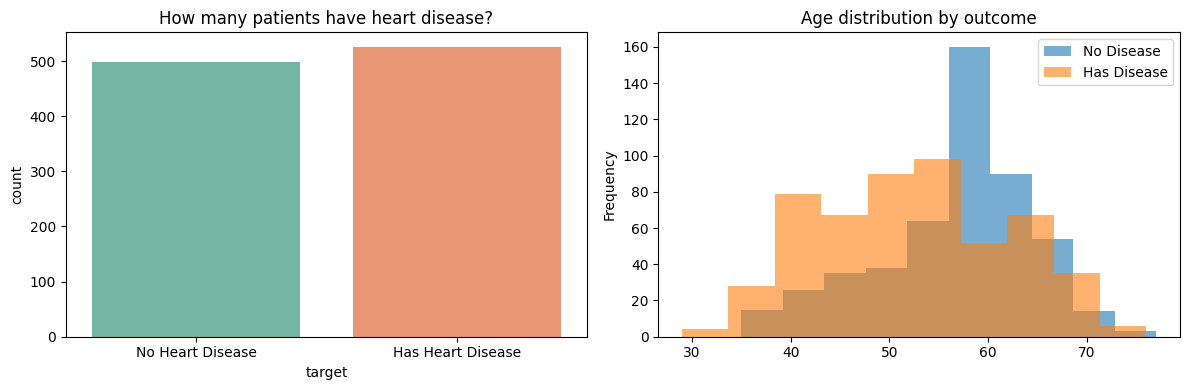

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4)) # chart of 1 row and 2 columns
sns.countplot(data=df, x='target', palette='Set2', ax=axes[0]) # draw a barchart with value counts
axes[0].set_title('How many patients have heart disease?')
axes[0].set_xticklabels(['No Heart Disease', 'Has Heart Disease']) # replace default lables

# split the data into two groups of sick and healthy patients
# plot a histogram for it
df.groupby('target')['age'].plot(kind='hist', alpha=0.6, ax=axes[1], legend=True)
axes[1].set_title('Age distribution by outcome')
axes[1].legend(['No Disease', 'Has Disease'])

plt.tight_layout() # adjust spacing so charts don't overlap or look cramped
plt.show() # then display everything

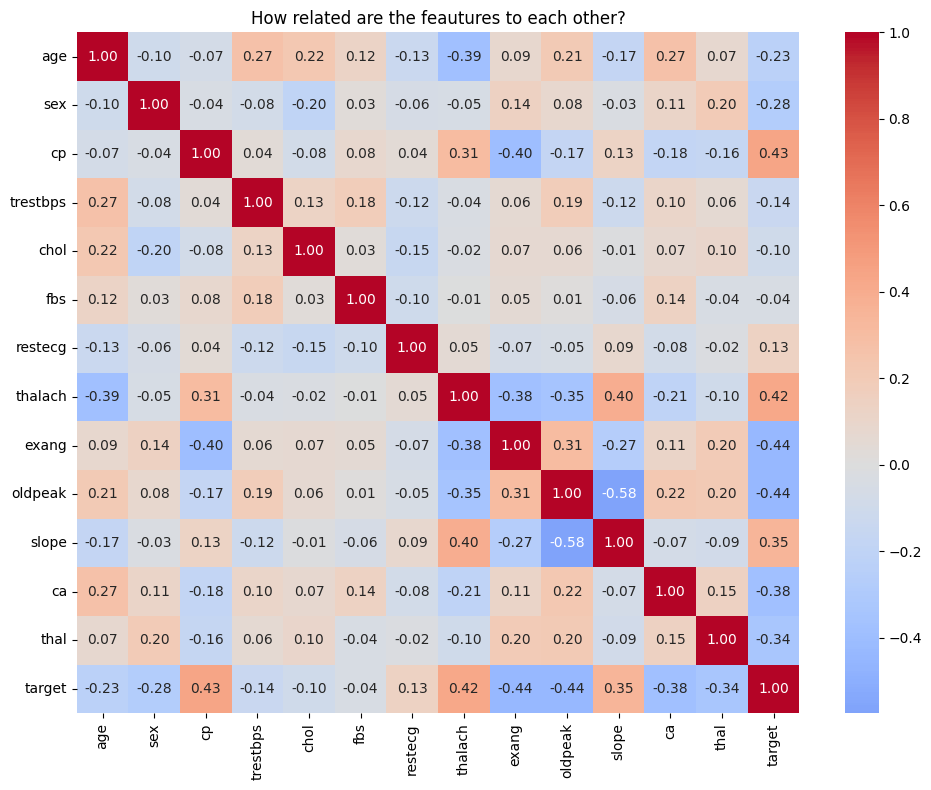

In [8]:
## Let's buid the heatmap
plt.figure(figsize=(10, 8))

# find the correlation btn every pair of columns, print them out in 2 decimal places
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('How related are the feautures to each other?')
plt.tight_layout()
plt.show()

In [9]:
# Here we will just split the features from the labels
X = df.drop('target', axis=1) # removed 'target' column from table
y = df['target'] # list of 1025 zeros and ones

print (f"Features: {X.shape[1]} | Patients: {X.shape[0]}") # 0 for rows and 1 for columns


Features: 13 | Patients: 1025


In [10]:
# Now, let's split them into training and testing sets
# shuffle the data and split into two piles.
# 4 things will be returned
# test 20% of the data and train 80%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training patients: {len(X_train)} | Test patients: {len(X_test)}")

Training patients: 820 | Test patients: 205


In [11]:
# Now, let's scale our data
# So, our model brings every column to the same range, centered around 0
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # for training
X_test_scaled = scaler.transform(X_test) # for testing data
                                         # No '.fit' here because we need to hide our testing data

print("Data is scaled and ready to go!")

Data is scaled and ready to go!


Here I am going to start of with **Logistic Regression** model and store it in a variable called lr.

This is a classification model with an imaginary line that is going to split my data into two categories of 1. probably have heart diseases or 2. probably without heart diseases.

I think it's the simplest of all three models I chose, that is why I am starting off with it.

In [12]:
lr = LogisticRegression(random_state=42)

lr.fit(X_train_scaled, y_train) # .fit is where learning happens
                                # we pass it our features and correct answers for each one
                                # and the model will adjust the combinations and find the best line to separate sick from healthy patients

lr_preds = lr.predict(X_test_scaled) # this predicts the testing batch
                                     # and returns 0's and 1's

lr_proba = lr.predict_proba(X_test_scaled)[:, 1] # this will give actual probability
                                                 # we will just pick the proba of having heart disease this time

print(f"Logistic Regression Accuracy: {accuracy_score(y_test, lr_preds): .2%}")
# this will help me to compare the accuracy of my model guesses to the real answers

Logistic Regression Accuracy:  80.98%


Second method is **Decision Tree**. We will give it the maximum depth of 4, so that it doesn't keep asking questions forever and not terminate.

Decision Tree Accuracy: 83.90%


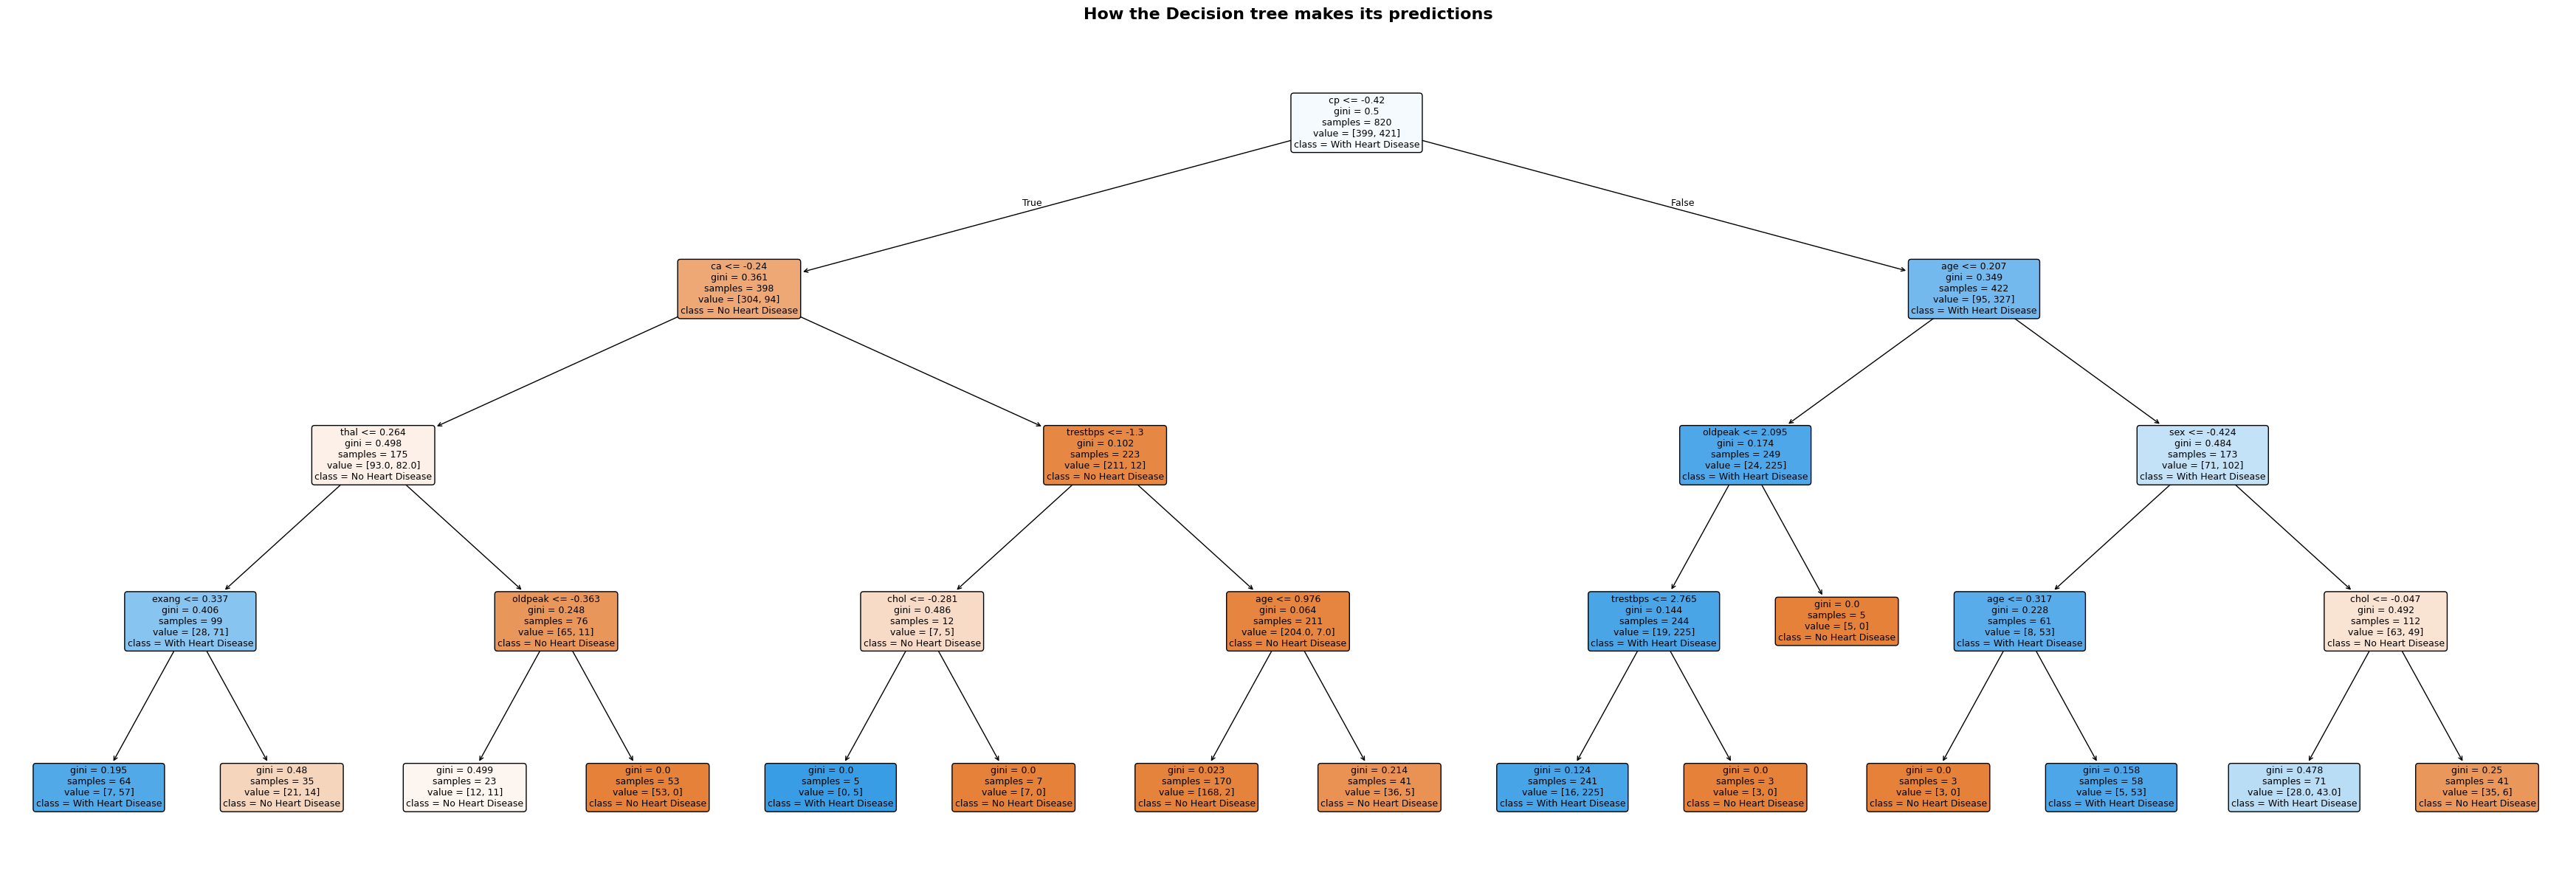

In [13]:
dt = DecisionTreeClassifier (max_depth=4, random_state=42)

# same logic as per Logistic Regression
# the pattern is basically to fit, predict and evaluate for our models
dt.fit(X_train_scaled, y_train)
dt_preds = dt.predict(X_test_scaled)
dt_proba = dt.predict_proba(X_test_scaled)[:, 1]

print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_preds):.2%}")

plt.figure(figsize=(35, 12)) # canvas of 35 inches wide and 12 inches tall

plot_tree(dt, feature_names=X.columns, class_names=["No Heart Disease", "With Heart Disease"],
          filled=True, rounded=True, fontsize=9)

plt.title('How the Decision tree makes its predictions', fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

Now, finally, we are going to add **Neural Network **model stored in nn. The neural network learns by making a guess, checking how wrong it was, and adjusting itself accordingly. It does this iteratively.

This is basically a series of rooms my data will pass through. The first one will have 64 neurons and the second one 32 because we have a small dataset. Each neuron will take a number and passes something forward.

We have 13 features to test in 64 and 32 rooms of neurons, then we shall get the predictions



In [14]:
nn = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42,
                   early_stopping=True, validation_fraction=0.1, alpha=0.01) # 10 % of training data to not overfit

nn.fit(X_train_scaled, y_train) # same .fit as in previous models

nn_preds = nn.predict(X_test_scaled)
nn_proba = nn.predict_proba(X_test_scaled)[:, 1]

print(f"Neural Network Accuracy: {accuracy_score(y_test, nn_preds):.2%}")

Neural Network Accuracy: 84.39%


In [15]:
print("""
My Neural Network initially returned 100% accuracy, which actually indicated overfitting.
The model had memorized the training data rather than learning generalizable patterns.
After adding early stopping and a regularization penalty, the accuracy dropped to 84.39%, a more realistic number,
which is actually, I think, a better and more trustworthy result.
""")


My Neural Network initially returned 100% accuracy, which actually indicated overfitting.
The model had memorized the training data rather than learning generalizable patterns.
After adding early stopping and a regularization penalty, the accuracy dropped to 84.39%, a more realistic number,
which is actually, I think, a better and more trustworthy result.



In [16]:
print("""
Model Accuracy Change Observation (comment):

Results showed a slight improvement as model complexity increased.
Logistic Regression achieved 80.98%, Decision Tree 83.90%, and Neural Network 84.39%.
However the marginal gain between the simplest and most complex model was only 3.41%,
suggesting that for a dataset this small, simpler models are nearly as effective as complex ones.

So, I think in this medical setting, I would suggest Logistic Regression model.
This is because it's the most explainable. A doctor can understand why it flagged a patient as high risk.


""")


Model Accuracy Change Observation (comment):

Results showed a slight improvement as model complexity increased.
Logistic Regression achieved 80.98%, Decision Tree 83.90%, and Neural Network 84.39%.
However the marginal gain between the simplest and most complex model was only 3.41%,
suggesting that for a dataset this small, simpler models are nearly as effective as complex ones.

So, I think in this medical setting, I would suggest Logistic Regression model.
This is because it's the most explainable. A doctor can understand why it flagged a patient as high risk.





Now, we need to build a set of confusion matrices, Receiver Operating Characteristics curves (ROC) and Comparison table comparing both three models.

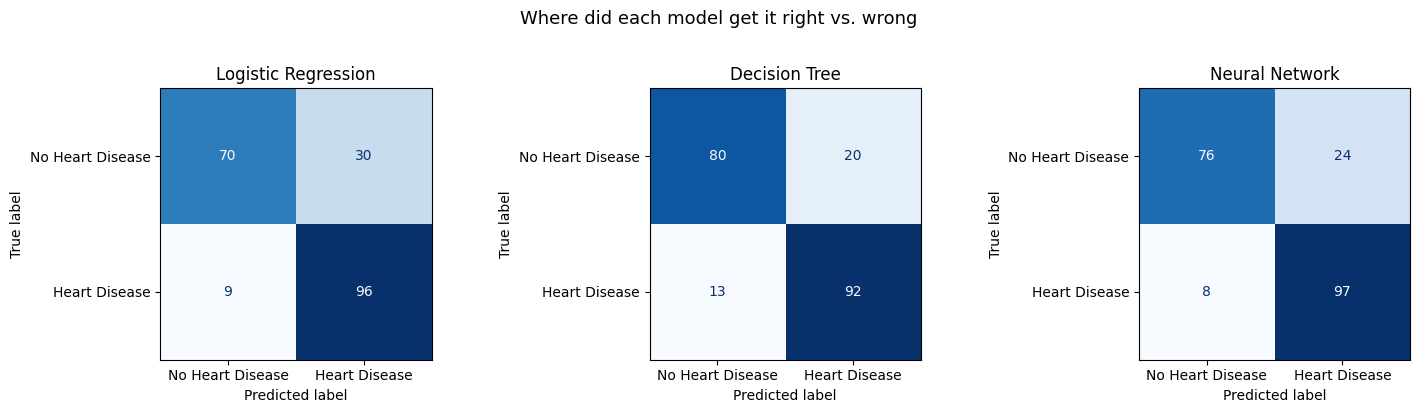

In [17]:
# Next, we will build confusion matrices for the models
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # three charts side by side

models_info = [
    (lr_preds, 'Logistic Regression'),
    (dt_preds, 'Decision Tree'),
    (nn_preds, 'Neural Network')
]

# loop through the models once per model
for ax, (preds, name) in zip (axes, models_info):
  cm = confusion_matrix(y_test, preds)

  disp = ConfusionMatrixDisplay(cm, display_labels=['No Heart Disease', 'Heart Disease'])

  disp.plot(ax=ax, colorbar=False, cmap="Blues")

  ax.set_title(name) # each chart with label name

plt.suptitle("Where did each model get it right vs. wrong", fontsize=13, y=1.02) # avoid overlaps
plt.tight_layout()
plt.show()



In [18]:
# Then we will do ROC Curves

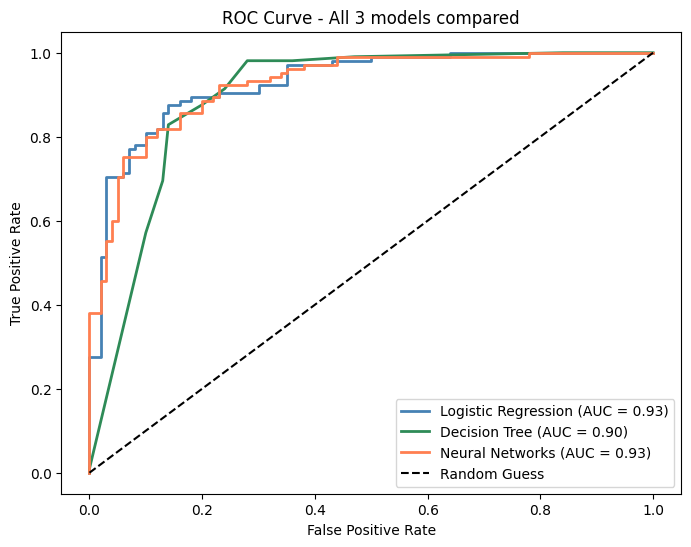

In [19]:
plt.figure(figsize=(8, 6))

for proba, name, color in [
    (lr_proba, "Logistic Regression", "steelblue"),
    (dt_proba, "Decision Tree", "seagreen"),
    (nn_proba, "Neural Networks", "coral")]:

    # calculate both False positive rate (fpr) and True positive rate (tpr)
    fpr, tpr, _ = roc_curve(y_test, proba)

    auc = roc_auc_score(y_test, proba) # auc stands for area under the curve

    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})", color=color, lw=2)

plt.plot([0, 1], [0, 1], "k--", label="Random Guess") # k-- is for dashing guessing model
                                                      # any model above this line is doing better than random

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - All 3 models compared")
plt.legend()
plt.show()


In [20]:
# Final model comparison table

In [21]:
from sklearn.metrics import f1_score, precision_score, recall_score

results = [] # list for models result

# loop through all the models
for name, preds, proba in [
    ("Logistic Regression", lr_preds, lr_proba),
    ("Decision Tree", dt_preds, dt_proba),
    ("Neural Network", nn_preds, nn_proba)]:

    results.append({
        'Model': name,
        'Accuracy': f"{accuracy_score(y_test, preds):.2%}",
        'F1_Score': f"{f1_score(y_test, preds):.2%}",
        'Precision': f"{precision_score(y_test, preds):.2%}",
        'Recall': f"{recall_score(y_test, preds):.2%}",
        'ROC-AUC': f"{roc_auc_score(y_test, proba):.2%}"
    })

pd.DataFrame(results).set_index("Model") # convert the list into a table

,Accuracy,F1_Score,Precision,Recall,ROC-AUC
Model,,,,,
Logistic Regression,80.98%,83.12%,76.19%,91.43%,92.98%
Decision Tree,83.90%,84.79%,82.14%,87.62%,89.57%
Neural Network,84.39%,85.84%,80.17%,92.38%,92.64%


In [22]:
print("""

Comment:
---------

While the Neural Network had the highest accuracy and recall, Logistic Regression actually achieved the highest ROC-AUC score,
meaning it was the best overall at distinguishing sick from healthy patients across different thresholds.
This suggests that for small structured datasets like this one, simpler models can be just as powerful — or even more powerful — than complex ones.
The added complexity of a Neural Network only gave a 3.41% accuracy gain, which may not justify its use in a real medical setting where explainability
and trust matter just as much as raw performance.

""")



Comment: 
---------

While the Neural Network had the highest accuracy and recall, Logistic Regression actually achieved the highest ROC-AUC score, 
meaning it was the best overall at distinguishing sick from healthy patients across different thresholds. 
This suggests that for small structured datasets like this one, simpler models can be just as powerful — or even more powerful — than complex ones. 
The added complexity of a Neural Network only gave a 3.41% accuracy gain, which may not justify its use in a real medical setting where explainability 
and trust matter just as much as raw performance.




Now, we will move to the final part of Feature importances...

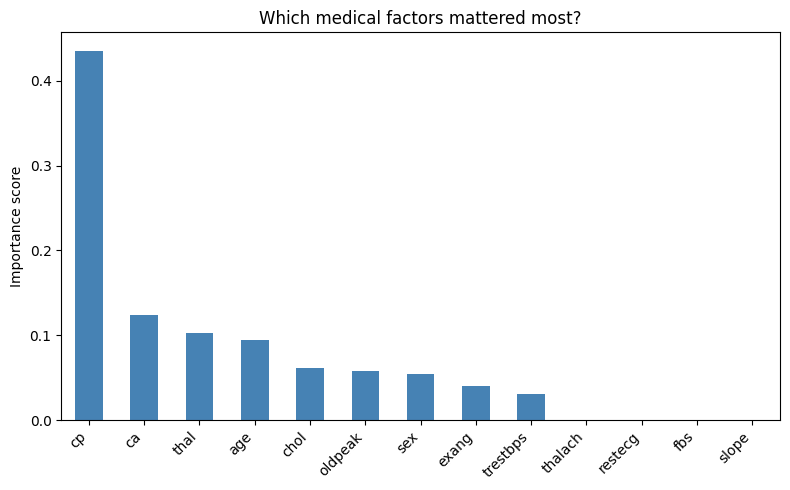

In [23]:
# Here, we will take a list of numbers and convert them into Panda series
# and we will sort everything from highest to lowest

importances = pd.Series(dt.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5)) # canvas of 8 inches wide and 5 tall

importances.plot(kind='bar', color='steelblue')

plt.title("Which medical factors mattered most?")
plt.ylabel('Importance score')
plt.xticks(rotation= 45, ha='right')
plt.tight_layout()
plt.show()

In [24]:
print("""
The feature importance chart revealed that chest pain type was by far the most influential factor,
accounting for 43% of all decisions made by the Decision Tree.

Interestingly, four features contributed almost nothing to predictions, suggesting that a simpler model
with fewer features might perform just as well.
""")


The feature importance chart revealed that chest pain type was by far the most influential factor, 
accounting for 43% of all decisions made by the Decision Tree. 

Interestingly, four features contributed almost nothing to predictions, suggesting that a simpler model 
with fewer features might perform just as well.



In [25]:
# next, let's do Cross Validation
for name, model in [
    ('Logistic Regression', lr),
    ('Decision Tree', dt),
    ('Neural Network', nn)]:
# Here we will split the training data into 5 equal folds
# Each time we will use 4 folds to train and 1 to test
# result will be a list of 5 accuracy numbers, one per experiment
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5)

    print(f"{name}: avg = {scores.mean():.2%} (+/- {scores.std():.2%})")
    # find the average and standard deviation of accuracy scores

Logistic Regression: avg = 84.39% (+/- 2.40%)
Decision Tree: avg = 85.49% (+/- 1.90%)
Neural Network: avg = 85.37% (+/- 2.78%)


In [26]:
print("""
Comment:
--------

Cross validation confirmed that all three models perform consistently, with averages between 84% and 86%.
The Decision Tree showed the lowest standard deviation at 1.90%, making it the most stable and predictable model
across different data splits.
The Neural Network, despite having competitive accuracy, showed the highest variation at 2.78%, suggesting it is
the least reliable of the three on this dataset size.

""")


Comment: 
--------

Cross validation confirmed that all three models perform consistently, with averages between 84% and 86%. 
The Decision Tree showed the lowest standard deviation at 1.90%, making it the most stable and predictable model 
across different data splits. 
The Neural Network, despite having competitive accuracy, showed the highest variation at 2.78%, suggesting it is 
the least reliable of the three on this dataset size.


